# County Poverty & Health Analysis

**Data:** `2025 County Health Rankings Data - v3.xlsx`

**Notebook auto-generated:** yes

This notebook reproduces the tasks laid out in the project plan for Members A–D. All visuals use matplotlib only and run fully offline.

> Tip: run the notebook top-to-bottom.

In [1]:

import pandas as pd
import numpy as np
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Display options
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)


## Load & Tidy the County Health Rankings data

In [3]:

# Path to the workbook (assumes it's next to this notebook)
path = Path("2025 County Health Rankings Data - v3.xlsx")
xls = pd.ExcelFile(path)

# We will use the 'Select Measure Data' sheet which is a wide table with a header row.
raw = pd.read_excel(xls, sheet_name="Select Measure Data")

# Build column names from the first row by forward-filling labels across columns
header_row = raw.iloc[0].astype(str).replace('nan', np.nan)
header_cat = header_row.ffill()

# Assign unique column names (deduplicate)
def dedupe(seq):
    seen = {}
    out = []
    for s in seq:
        name = str(s)
        if name in seen:
            seen[name] += 1
            name = f"{name}__{seen[name]}"
        else:
            seen[name] = 0
        out.append(name)
    return out

raw.columns = dedupe(header_cat)
data = raw.iloc[1:].reset_index(drop=True)

# Standard identifiers
loc_cols = ['FIPS', 'State', 'County']
# Keep only if present
loc_cols = [c for c in loc_cols if c in data.columns]

# Numeric coercion helper (for later)
def to_numeric(df, exclude=()):
    out = df.copy()
    for col in out.columns:
        if col not in exclude:
            out[col] = pd.to_numeric(out[col], errors='coerce')
    return out

data.sample(3)


,FIPS,State,County,Unreliable,Deaths,Years of Potential Life Lost Rate,95% CI - Low,95% CI - High,National Z-Score,YPLL Rate (Hispanic (all races)),YPLL Rate (Hispanic (all races)) 95% CI - Low,YPLL Rate (Hispanic (all races)) 95% CI - High,YPLL Rate (Hispanic (all races)) Unreliable,YPLL Rate (Non-Hispanic AIAN),YPLL Rate (Non-Hispanic AIAN) 95% CI - Low,YPLL Rate (Non-Hispanic AIAN) 95% CI - High,YPLL Rate (Non-Hispanic AIAN) Unreliable,YPLL Rate (Non-Hispanic Asian),YPLL Rate (Non-Hispanic Asian) 95% CI - Low,YPLL Rate (Non-Hispanic Asian) 95% CI - High,YPLL Rate (Non-Hispanic Asian) Unreliable,YPLL Rate (Non-Hispanic Black),YPLL Rate (Non-Hispanic Black) 95% CI - Low,YPLL Rate (Non-Hispanic Black) 95% CI - High,YPLL Rate (Non-Hispanic Black) Unreliable,YPLL Rate (Non-Hispanic Native Hawaiian and Other Pacific Islander),YPLL Rate (Non-Hispanic Native Hawaiian and Other Pacific Islander) 95% CI - Low,YPLL Rate (Non-Hispanic Native Hawaiian and Other Pacific Islander) 95% CI - High,YPLL Rate (Non-Hispanic Native Hawaiian and Other Pacific Islander) Unreliable,YPLL Rate (Non-Hispanic 2+ races),YPLL Rate (Non-Hispanic 2+ races) 95% CI - Low,YPLL Rate (Non-Hispanic 2+ races) 95% CI - High,YPLL Rate (Non-Hispanic 2+ races) Unreliable,YPLL Rate (Non-Hispanic White),YPLL Rate (Non-Hispanic White) 95% CI - Low,YPLL Rate (Non-Hispanic White) 95% CI - High,YPLL Rate (Non-Hispanic White) Unreliable,Average Number of Physically Unhealthy Days,95% CI - Low__1,95% CI - High__1,National Z-Score__1,Unreliable__1,% Low Birth Weight,95% CI - Low__2,95% CI - High__2,National Z-Score__2,% LBW (Hispanic (all races)),% LBW (Hispanic (all races)) 95% CI - Low,% LBW (Hispanic (all races)) 95% CI - High,% LBW (Non-Hispanic AIAN),% LBW (Non-Hispanic AIAN) 95% CI - Low,% LBW (Non-Hispanic AIAN) 95% CI - High,% LBW (Non-Hispanic Asian),% LBW (Non-Hispanic Asian) 95% CI - Low,% LBW (Non-Hispanic Asian) 95% CI - High,% LBW (Non-Hispanic Black),% LBW (Non-Hispanic Black) 95% CI - Low,% LBW (Non-Hispanic Black) 95% CI - High,% LBW (Non-Hispanic Native Hawaiian and Other Pacific Islander),% LBW (Non-Hispanic Native Hawaiian and Other Pacific Islander) 95% CI - Low,...,# Some College,Population,% Some College,95% CI - Low__10,95% CI - High__10,National Z-Score__21,# Completed High School,Population__1,% Completed High School,95% CI - Low__11,95% CI - High__11,National Z-Score__22,# Unemployed,Labor Force,% Unemployed,National Z-Score__23,80th Percentile Income,20th Percentile Income,Income Ratio,National Z-Score__24,% Children in Poverty,95% CI - Low__12,95% CI - High__12,National Z-Score__25,% Children in Poverty (AIAN),% Children in Poverty (Asian),% Children in Poverty (Black),% Children in Poverty (Hispanic),% Children in Poverty (White),# Injury Deaths,Injury Death Rate,95% CI - Low__13,95% CI - High__13,National Z-Score__26,Injury Death Rate (Hispanic (all races)),Injury Death Rate (Hispanic (all races)) 95% CI - Low,Injury Death Rate (Hispanic (all races)) 95% CI - High,Injury Death Rate (Non-Hispanic AIAN),Injury Death Rate (Non-Hispanic AIAN) 95% CI - Low,Injury Death Rate (Non-Hispanic AIAN) 95% CI - High,Injury Death Rate (Non-Hispanic Asian),Injury Death Rate (Non-Hispanic Asian) 95% CI - Low,Injury Death Rate (Non-Hispanic Asian) 95% CI - High,Injury Death Rate (Non-Hispanic Black),Injury Death Rate (Non-Hispanic Black) 95% CI - Low,Injury Death Rate (Non-Hispanic Black) 95% CI - High,Injury Death Rate (Non-Hispanic Native Hawaiian and Other Pacific Islander),Injury Death Rate (Non-Hispanic Native Hawaiian and Other Pacific Islander) 95% CI - Low,Injury Death Rate (Non-Hispanic Native Hawaiian and Other Pacific Islander) 95% CI - High,Injury Death Rate (Non-Hispanic 2+ races),Injury Death Rate (Non-Hispanic 2+ races) 95% CI - Low,Injury Death Rate (Non-Hispanic 2+ races) 95% CI - High,Injury Death Rate (Non-Hispanic White),Injury Death Rate (Non-Hispanic White) 95% CI - Low,Injury Death Rate (Non-Hispanic White) 95% CI - High,# Associations,Soci

## Member A – Poverty / Economic Data Lead
We use **% Children in Poverty** as the poverty proxy (overall poverty % not present on this sheet). If a **Median Household Income** column exists, we will use it; otherwise, we note its absence and proceed with available income measures.

Top 10 counties by % Children in Poverty:


,FIPS,State,County,% Children in Poverty
1468,28055,Mississippi,Issaquena,63.2
2485,46137,South Dakota,Ziebach,55.7
1051,21051,Kentucky,Clay,53.6
1105,21159,Kentucky,Martin,53.2
1164,22035,Louisiana,East Carroll,52.8
1503,28125,Mississippi,Sharkey,51.5
53,01105,Alabama,Perry,50.3
66,01131,Alabama,Wilcox,48.5
1179,22065,Louisiana,Madison,48.1
1467,28053,Mississippi,Humphreys,47.1



Bottom 10 counties by % Children in Poverty:


,FIPS,State,County,% Children in Poverty
274,08035,Colorado,Douglas,3.1
1857,35028,New Mexico,Los Alamos,3.4
3159,55089,Wisconsin,Ozaukee,3.7
2459,46083,South Dakota,Lincoln,3.8
1362,27019,Minnesota,Carver,3.8
2989,51610,Virginia,Falls Church City,4.0
2935,51107,Virginia,Loudoun,4.0
1829,34019,New Jersey,Hunterdon,4.3
3181,55133,Wisconsin,Waukesha,4.4
2852,49029,Utah,Morgan,4.4


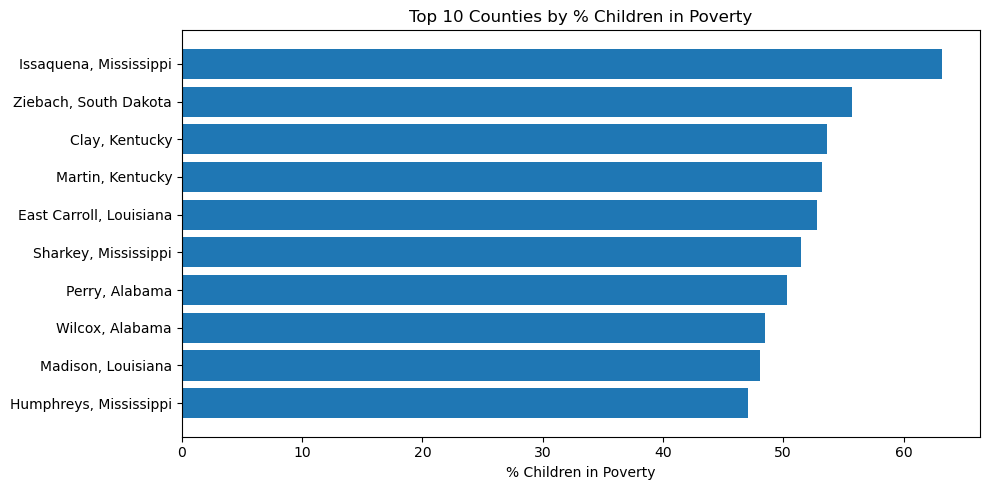

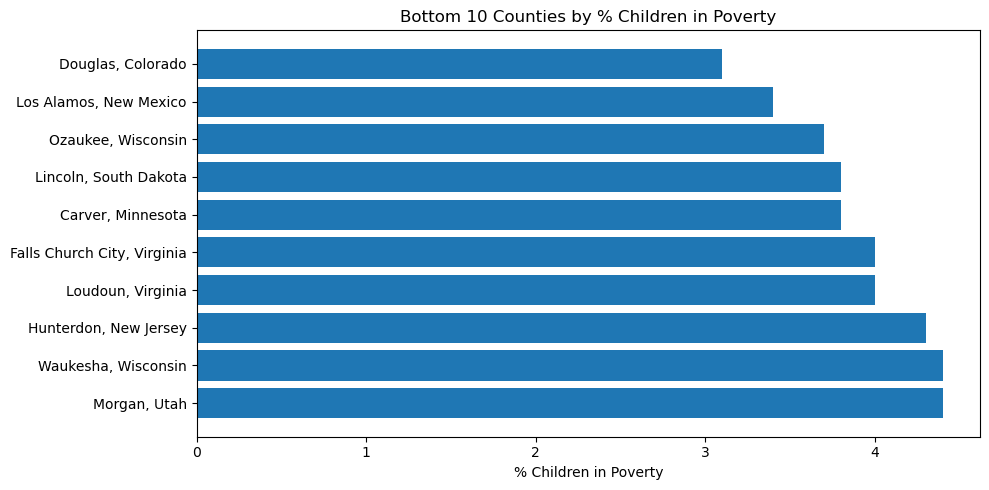

Median Household Income column not found in this sheet; skipping that scatterplot.


In [5]:

# Identify target poverty metric
poverty_col = "% Children in Poverty"
assert poverty_col in data.columns, "Poverty column not found (% Children in Poverty)."

# Try to find Median Household Income if present
mhi_candidates = [c for c in data.columns if re.search(r'Median Household Income', str(c), re.I)]
mhi_col = mhi_candidates[0] if mhi_candidates else None

# Build a minimal frame for Member A
keep_A = loc_cols + [poverty_col]
if mhi_col: keep_A.append(mhi_col)

A_df = data[keep_A].copy()
A_df = to_numeric(A_df, exclude=loc_cols)

# Top 10 / Bottom 10 counties by poverty
A_df_nonan = A_df.dropna(subset=[poverty_col])
top10 = A_df_nonan.sort_values(poverty_col, ascending=False).head(10)
bottom10 = A_df_nonan.sort_values(poverty_col, ascending=True).head(10)

print("Top 10 counties by % Children in Poverty:")
display(top10[loc_cols + [poverty_col]])

print("\nBottom 10 counties by % Children in Poverty:")
display(bottom10[loc_cols + [poverty_col]])

# Bar charts: top/bottom
fig, ax = plt.subplots(figsize=(10,5))
ax.barh(top10.apply(lambda r: f"{r['County']}, {r['State']}", axis=1), top10[poverty_col])
ax.invert_yaxis()
ax.set_title("Top 10 Counties by % Children in Poverty")
ax.set_xlabel("% Children in Poverty")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10,5))
ax.barh(bottom10.apply(lambda r: f"{r['County']}, {r['State']}", axis=1), bottom10[poverty_col])
ax.invert_yaxis()
ax.set_title("Bottom 10 Counties by % Children in Poverty")
ax.set_xlabel("% Children in Poverty")
plt.tight_layout()
plt.show()

# Scatter: Median Household Income vs Poverty (if MHI available)
if mhi_col:
    m = A_df_nonan.dropna(subset=[mhi_col])
    fig, ax = plt.subplots(figsize=(6,5))
    ax.scatter(m[mhi_col], m[poverty_col], s=8, alpha=0.5)
    # Simple regression line
    x = m[mhi_col].values
    y = m[poverty_col].values
    coef = np.polyfit(x, y, 1)
    trend = np.poly1d(coef)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, trend(xs))
    ax.set_xlabel("Median Household Income")
    ax.set_ylabel("% Children in Poverty")
    ax.set_title("Income vs Poverty (counties)")
    plt.tight_layout()
    plt.show()
else:
    print("Median Household Income column not found in this sheet; skipping that scatterplot.")


> **Map note:** County-choropleth normally requires a county GeoJSON; since this notebook runs offline without web access, a county map layer isn’t included by default. If you provide a local GeoJSON of US counties, add a mapping cell to render a choropleth by FIPS.

## Member B – Health Outcomes Analyst
We analyze Life Expectancy, Premature Death (YPLL), Poor/Fair Health, and Frequent Mental Distress where available.

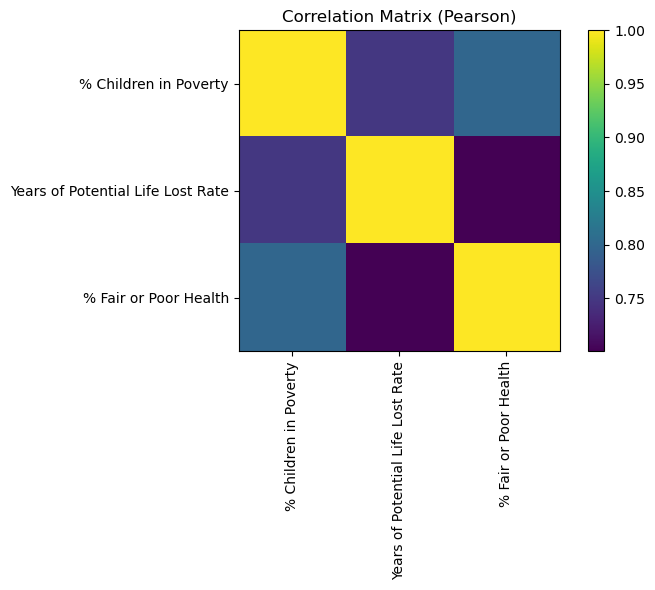

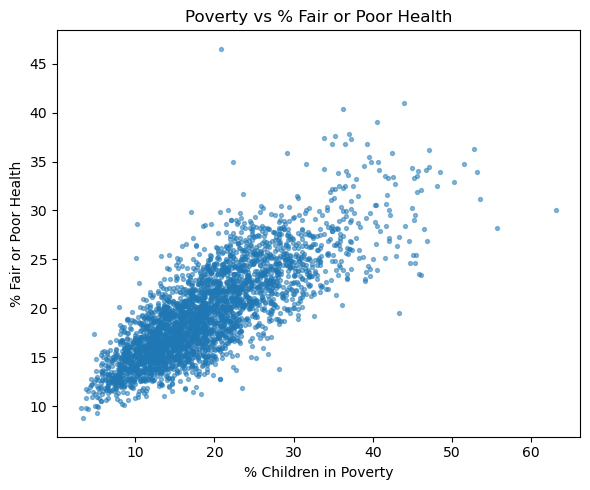

In [7]:

# Candidate columns for outcomes
outcome_keys = [
    'Life Expectancy', 'Premature Death', 'Years of Potential Life Lost Rate',
    '% Fair or Poor Health', 'Frequent Mental Distress', '% Frequent Mental Distress',
]

outcome_cols = [c for c in data.columns if any(k.lower() in c.lower() for k in outcome_keys)]
outcome_cols = list(dict.fromkeys(outcome_cols))  # preserve order, unique

B_df = data[loc_cols + [poverty_col] + outcome_cols].copy()
B_df = to_numeric(B_df, exclude=loc_cols)

# Correlation heatmap data (matplotlib imshow without seaborn)
corr_df = B_df.drop(columns=loc_cols).corr(method='pearson')
labels = corr_df.columns.tolist()

fig, ax = plt.subplots(figsize=(8,6))
cax = ax.imshow(corr_df.values, interpolation='nearest')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=90)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_title("Correlation Matrix (Pearson)")
fig.colorbar(cax)
plt.tight_layout()
plt.show()

# Scatterplots: poverty vs. two key outcomes
for ycol in [col for col in ['Life Expectancy', '% Fair or Poor Health'] if col in B_df.columns]:
    m = B_df[[poverty_col, ycol]].dropna()
    fig, ax = plt.subplots(figsize=(6,5))
    ax.scatter(m[poverty_col], m[ycol], s=8, alpha=0.5)
    ax.set_xlabel("% Children in Poverty")
    ax.set_ylabel(ycol)
    ax.set_title(f"Poverty vs {ycol}")
    plt.tight_layout()
    plt.show()

# Boxplots: poverty quartiles vs Life Expectancy
if 'Life Expectancy' in B_df.columns:
    tmp = B_df[[poverty_col, 'Life Expectancy']].dropna().copy()
    tmp['Poverty Quartile'] = pd.qcut(tmp[poverty_col], 4, labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])
    # Build boxplots with matplotlib
    groups = [tmp.loc[tmp['Poverty Quartile']==q, 'Life Expectancy'] for q in ['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)']]
    fig, ax = plt.subplots(figsize=(7,5))
    ax.boxplot(groups, labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])
    ax.set_title("Life Expectancy by Poverty Quartile")
    ax.set_ylabel("Life Expectancy (years)")
    plt.tight_layout()
    plt.show()

# Outlier analysis: counties that 'beat the odds' (residuals from linear fit LE ~ poverty)
if 'Life Expectancy' in B_df.columns:
    m = B_df[[poverty_col, 'Life Expectancy']].dropna()
    x = m[poverty_col].values
    y = m['Life Expectancy'].values
    coef = np.polyfit(x, y, 1)
    pred = np.poly1d(coef)(x)
    resid = y - pred
    m2 = m.copy()
    m2['Residual_LE'] = resid
    # Show top 10 positive residuals (better than expected)
    print("Counties with highest positive residuals (higher LE than expected for poverty):")
    display(m2.nlargest(10, 'Residual_LE'))


## Member C – Health Behaviors & Clinical Care Analyst
We examine Smoking, Obesity, Physical Inactivity, Excessive Drinking, Teen Births, Uninsured Rate, Primary Care Physicians Ratio, and Preventable Hospitalization Rate.

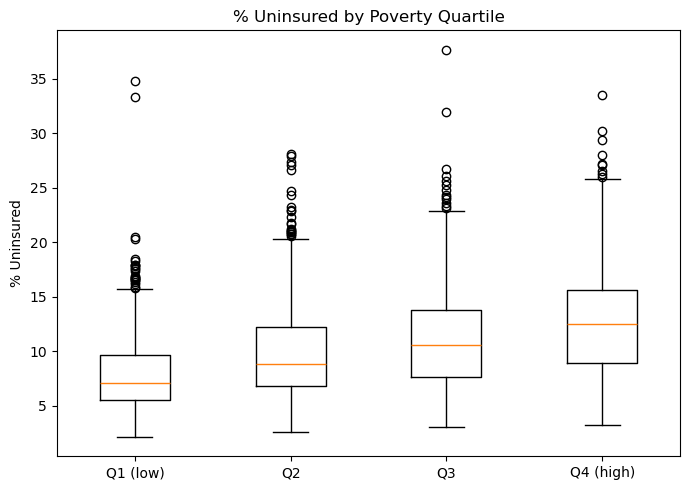

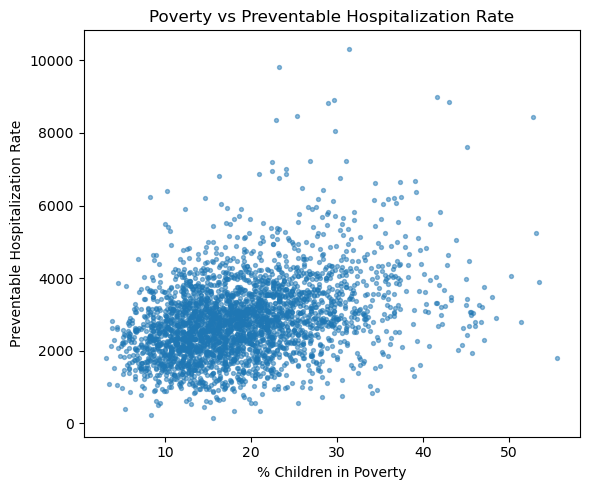

IndexError: index -1 is out of bounds for axis 0 with size 0

In [9]:

behav_keys = [
    'Smoking', 'Smokers', '% Smok', 'Adult Obesity', '% Obese',
    '% Physical Inactivity', 'Excessive Drinking', 'Teen Birth',
    '% Uninsured', 'Primary Care Physicians Ratio', 'Preventable Hospitalization Rate'
]

behav_cols = [c for c in data.columns if any(k.lower() in c.lower() for k in behav_keys)]
behav_cols = list(dict.fromkeys(behav_cols))

C_df = data[loc_cols + [poverty_col] + behav_cols].copy()
C_df = to_numeric(C_df, exclude=loc_cols)

# Side-by-side boxplots: poverty quartiles vs selected variables
box_vars = [v for v in ['% Uninsured', 'Adult Obesity', '% Smokers', '% Smoking', '% Physical Inactivity'] if v in C_df.columns]
if box_vars:
    tmp = C_df[[poverty_col] + box_vars].dropna()
    tmp['Poverty Quartile'] = pd.qcut(tmp[poverty_col], 4, labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])
    for v in box_vars:
        fig, ax = plt.subplots(figsize=(7,5))
        groups = [tmp.loc[tmp['Poverty Quartile']==q, v] for q in ['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)']]
        ax.boxplot(groups, labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])
        ax.set_title(f"{v} by Poverty Quartile")
        ax.set_ylabel(v)
        plt.tight_layout()
        plt.show()

# Scatter: poverty vs preventable hospital stays (if available)
ycol = 'Preventable Hospitalization Rate'
if ycol in C_df.columns:
    m = C_df[[poverty_col, ycol]].dropna()
    fig, ax = plt.subplots(figsize=(6,5))
    ax.scatter(m[poverty_col], m[ycol], s=8, alpha=0.5)
    ax.set_xlabel("% Children in Poverty")
    ax.set_ylabel(ycol)
    ax.set_title(f"Poverty vs {ycol}")
    plt.tight_layout()
    plt.show()

# Compare physician density in high vs low poverty
pcp = 'Primary Care Physicians Ratio'
if pcp in C_df.columns:
    tmp = C_df[[poverty_col, pcp]].dropna()
    tmp['Poverty Bin'] = pd.qcut(tmp[poverty_col], 2, labels=['Low poverty', 'High poverty'])
    means = tmp.groupby('Poverty Bin')[pcp].mean()
    fig, ax = plt.subplots(figsize=(6,4))
    ax.bar(means.index, means.values)
    ax.set_title("Primary Care Physician Ratio by Poverty Half")
    ax.set_ylabel("Population per PCP (higher = fewer physicians)")
    plt.tight_layout()
    plt.show()


## Member D – Social & Environmental Analyst
We analyze Unemployment, High School Graduation / Completion, Severe Housing Problems/Cost Burden, Income Inequality, and Air Pollution if present.

Correlation with Poverty (social & environmental):


,% Children in Poverty
% Children in Poverty,1.000000
% Completed High School,-0.644297
Income Ratio,0.584620
% Unemployed,0.464729
% Severe Housing Problems,0.223628
Severe Housing Cost Burden 95% CI - High,0.222720
Severe Housing Cost Burden,0.133272
Average Daily PM2.5,0.059465
Severe Housing Cost Burden 95% CI - Low,-0.040881


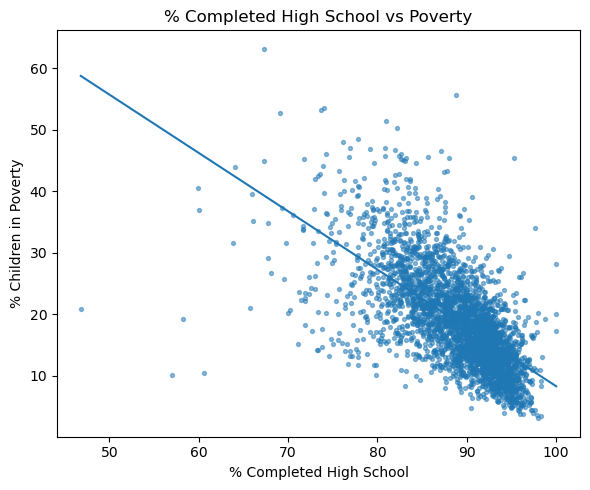

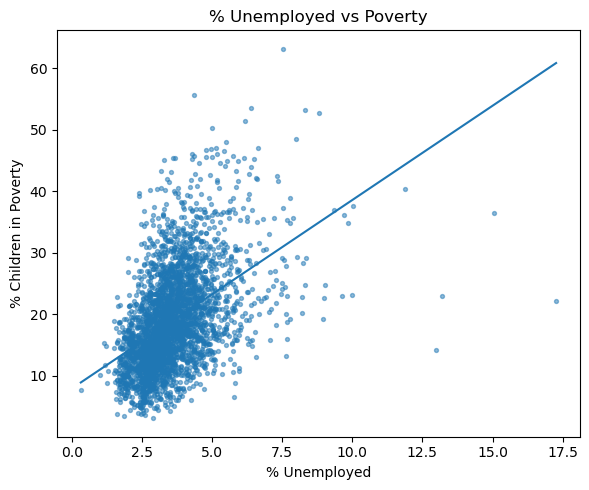

/var/folders/2c/2yygkhlx77sbtpg2m6lwc55c0000gn/T/ipykernel_43594/556461524.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = tmp.groupby('Poverty Quartile')[hcol].mean()


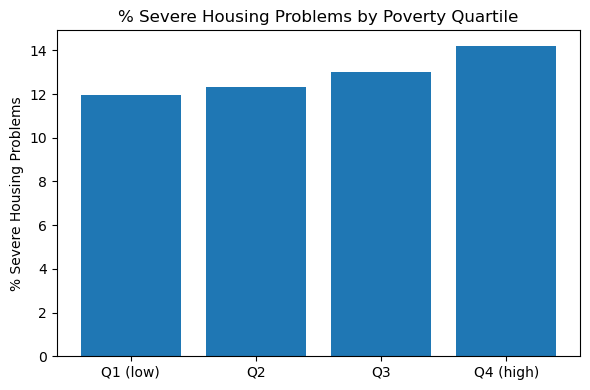

In [11]:

social_keys = [
    '% Unemployed', 'Unemployment', 'High School Graduation', '% Completed High School',
    '% Severe Housing Problems', 'Severe Housing Cost Burden', 'Income Ratio', 'Air Pollution', 'PM2.5'
]

social_cols = [c for c in data.columns if any(k.lower() in c.lower() for k in social_keys)]
social_cols = list(dict.fromkeys(social_cols))

D_df = data[loc_cols + [poverty_col] + social_cols].copy()
D_df = to_numeric(D_df, exclude=loc_cols)

# Correlation sub-matrix: poverty vs social/env
corr_sub = D_df.drop(columns=loc_cols).corr(method='pearson')[[poverty_col]].sort_values(by=poverty_col, key=np.abs, ascending=False)
print("Correlation with Poverty (social & environmental):")
display(corr_sub)

# Scatter examples: education & unemployment vs poverty
for ycol in [col for col in ['% Completed High School', '% Unemployed'] if col in D_df.columns]:
    m = D_df[[poverty_col, ycol]].dropna()
    fig, ax = plt.subplots(figsize=(6,5))
    ax.scatter(m[ycol], m[poverty_col], s=8, alpha=0.5)
    # Add trend line
    x = m[ycol].values; y = m[poverty_col].values
    coef = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, np.poly1d(coef)(xs))
    ax.set_xlabel(ycol)
    ax.set_ylabel("% Children in Poverty")
    ax.set_title(f"{ycol} vs Poverty")
    plt.tight_layout()
    plt.show()

# Bar chart: average housing problem % across poverty quartiles (if present)
hcol = '% Severe Housing Problems'
if hcol in D_df.columns:
    tmp = D_df[[poverty_col, hcol]].dropna()
    tmp['Poverty Quartile'] = pd.qcut(tmp[poverty_col], 4, labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])
    means = tmp.groupby('Poverty Quartile')[hcol].mean()
    fig, ax = plt.subplots(figsize=(6,4))
    ax.bar(means.index.astype(str), means.values)
    ax.set_title("% Severe Housing Problems by Poverty Quartile")
    ax.set_ylabel("% Severe Housing Problems")
    plt.tight_layout()
    plt.show()
